In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("xy_data.csv")

# Display first few rows
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Basic statistics
print("\nStatistics:")
print(df.describe())

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB
None

Statistics:
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


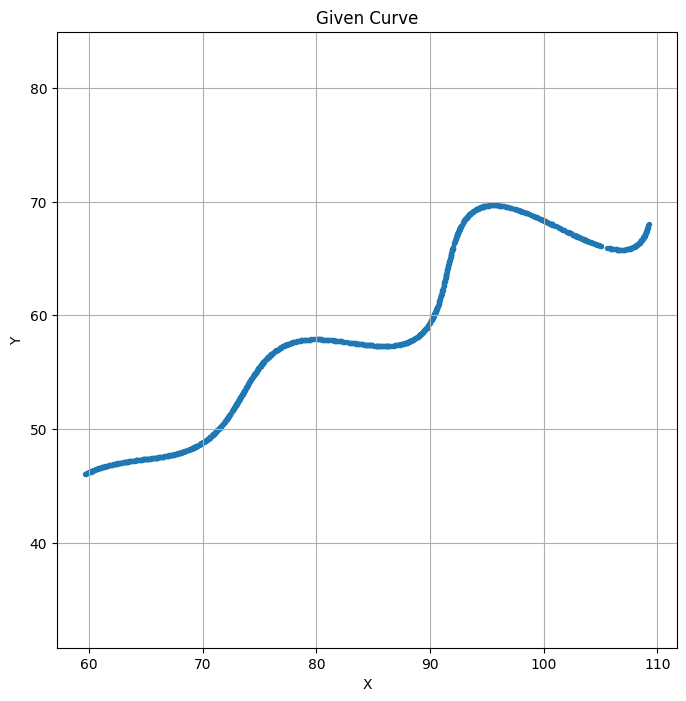

In [3]:
plt.figure(figsize=(8,8))

plt.scatter(df["x"], df["y"], s=8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Given Curve")
plt.grid(True)
plt.axis("equal")

plt.show()



In [4]:
# Sort by x (hypothesis: monotonic in t)
df_sorted = df.sort_values("x").reset_index(drop=True)

# Assume uniform t
t_data = np.linspace(6, 60, len(df_sorted))

x_data = df_sorted["x"].values
y_data = df_sorted["y"].values

In [5]:
from scipy.optimize import least_squares

def residuals(params, t, x_data, y_data):
    theta, M, X = params
    x_model = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
    y_model = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    return np.concatenate([x_model - x_data, y_model - y_data])

p0 = [0.3, 0.02, 50]  # initial guess
bounds_lower = [0, -0.05, 0]
bounds_upper = [np.radians(50), 0.05, 100]

result = least_squares(
    residuals, p0,
    args=(t_data, x_data, y_data),
    bounds=(bounds_lower, bounds_upper),
    loss='soft_l1'
)

theta_fit, M_fit, X_fit = result.x
print("theta (rad):", theta_fit, " theta (deg):", np.degrees(theta_fit))
print("M:", M_fit)
print("X:", X_fit)

theta (rad): 0.5251557122506963  theta (deg): 30.089205899151604
M: 0.029910491096938715
X: 55.01458058723268


In [6]:
def model_curve(theta, M, X, t):
    x = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
    y = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    return x, y

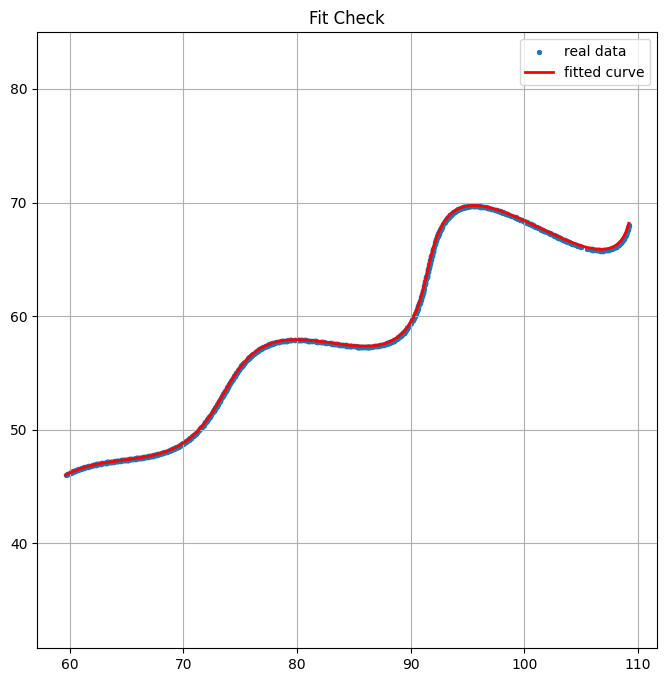

In [7]:
x_pred, y_pred = model_curve(theta_fit, M_fit, X_fit, t_data)

plt.figure(figsize=(8,8))
plt.scatter(df["x"], df["y"], s=8, label="real data")
plt.plot(x_pred, y_pred, color="red", linewidth=2, label="fitted curve")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.title("Fit Check")
plt.show()

In [8]:
errors = np.abs(x_pred - x_data) + np.abs(y_pred - y_data)
print("Mean L1 error per point:", errors.mean())
print("Max L1 error:", errors.max())


Mean L1 error per point: 0.30489773180135427
Max L1 error: 1.1836259548197887


In [9]:
print("Optimization Status :", "Success" if result.success else "Failed")
print("Iterations          :", result.nfev)
errors = np.abs(x_pred - x_data) + np.abs(y_pred - y_data)
print("Total Error         :", errors.sum())
print("Average Error/Point  :", errors.mean())

Optimization Status : Success
Iterations          : 12
Total Error         : 457.34659770203143
Average Error/Point  : 0.30489773180135427
